In [1]:
# ============================================
# IRIS FLOWER CLASSIFICATION 🌸
# My First Kaggle Notebook
# ============================================

# --- 1. LIBRARIES ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# --- 2. LOAD DATA ---
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['flower'] = df['target'].map({0:'Setosa', 1:'Versicolor', 2:'Virginica'})

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (150, 6)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


Basic Info:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

Missing Values:
sepal length (cm)    0
sepal width (cm)    

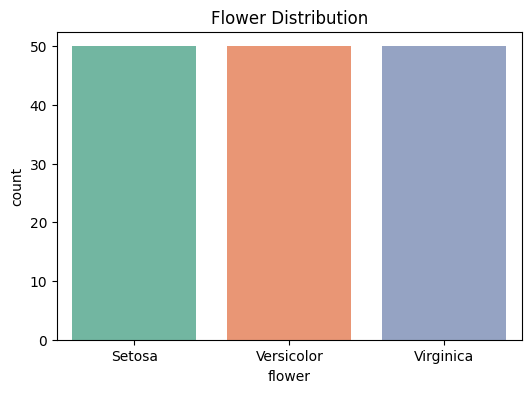

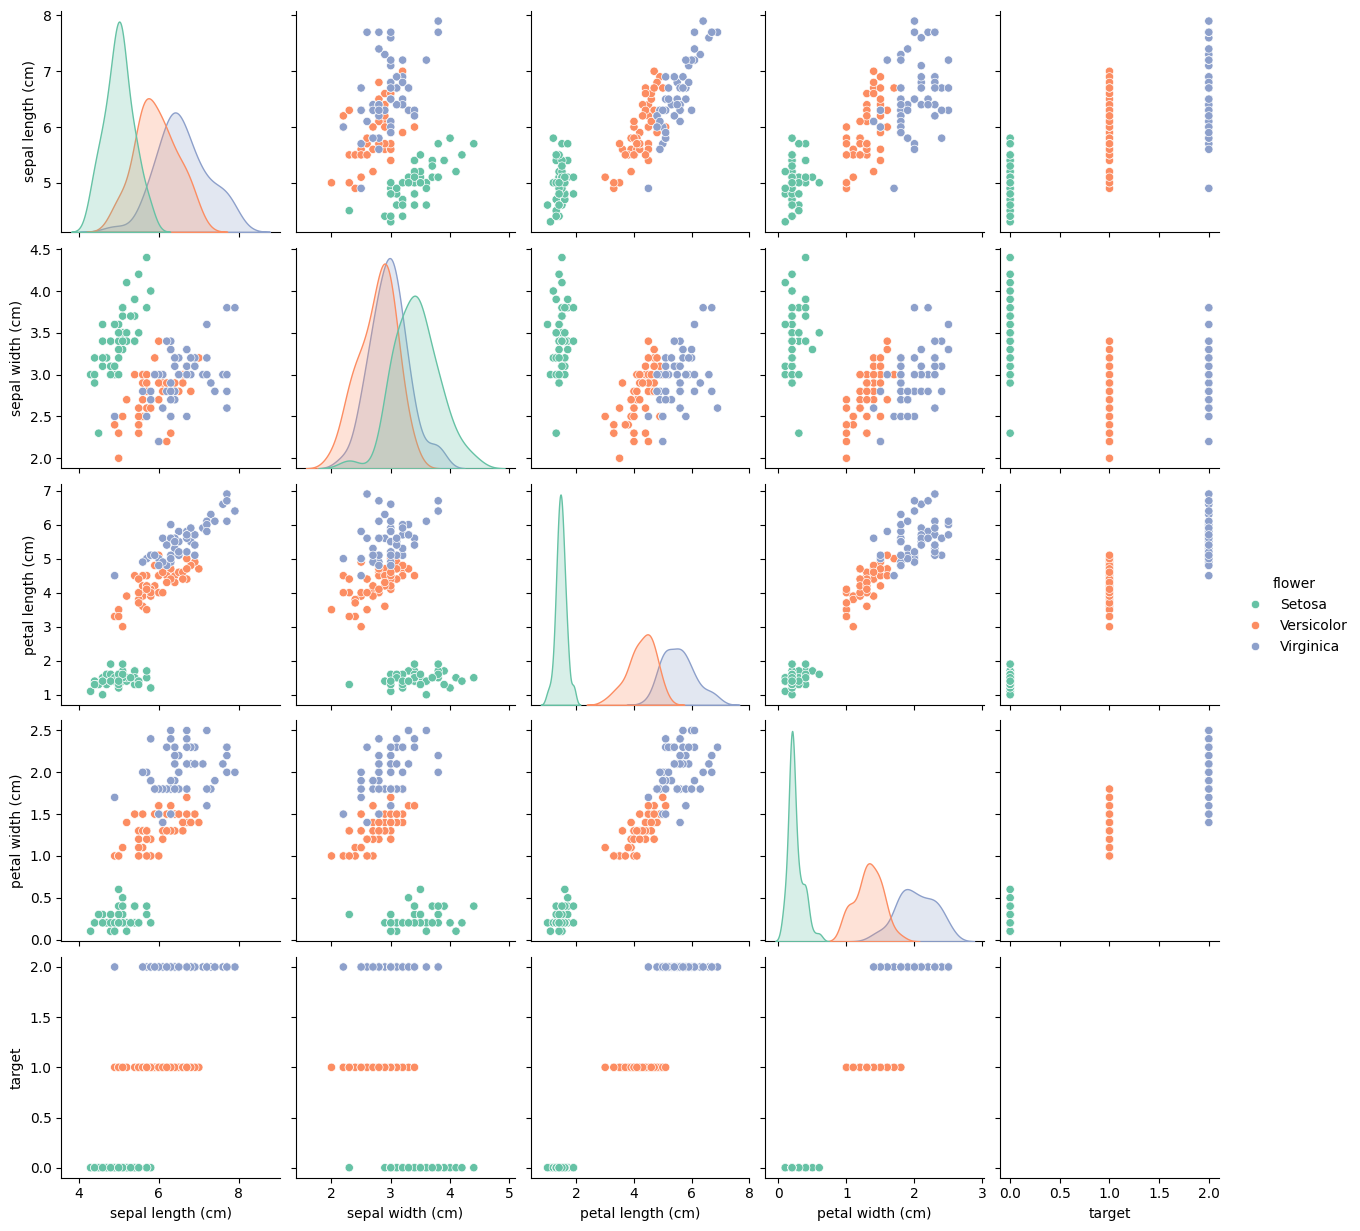

In [2]:
# --- 3. EDA ---
print("Basic Info:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# Countplot
plt.figure(figsize=(6,4))
sns.countplot(x='flower', data=df, palette='Set2')
plt.title("Flower Distribution")
plt.show()

# Pairplot
sns.pairplot(df, hue='flower', palette='Set2')
plt.show()

In [3]:
# --- 4. MODEL TRAINING ---

# Features & Target
X = df[iris.feature_names]
y = df['target']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("✅ Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

✅ Accuracy: 100.0 %


              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



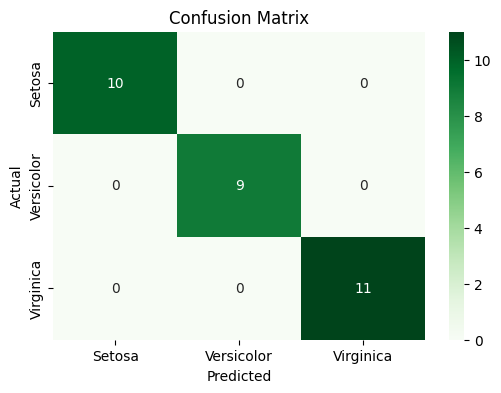

In [4]:
# --- 5. EVALUATION ---

# Classification Report
print(classification_report(y_test, y_pred, 
      target_names=['Setosa','Versicolor','Virginica']))

# Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Setosa','Versicolor','Virginica'],
            yticklabels=['Setosa','Versicolor','Virginica'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

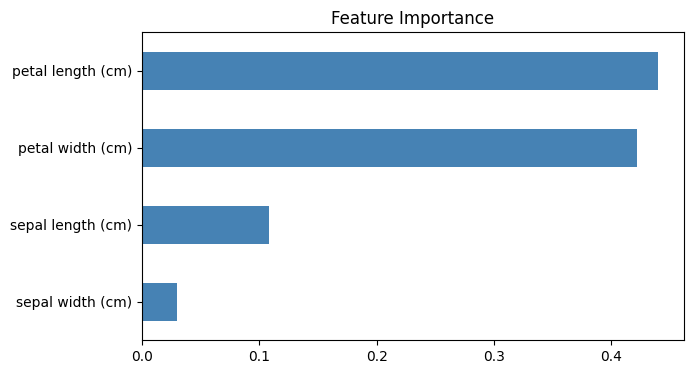

In [5]:
# --- 6. FEATURE IMPORTANCE ---
feat_imp = pd.Series(model.feature_importances_, index=iris.feature_names)
feat_imp.sort_values().plot(kind='barh', color='steelblue', figsize=(7,4))
plt.title("Feature Importance")
plt.show()